In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def load_log(path):
    df = pd.read_csv(
        path,
        sep=" ",
        names=["t", "x", "y", "yaw"],
        engine="python"
    )
    return df


In [ ]:
def nearest(df_ref, df_query):
    idx = np.searchsorted(df_ref["t"].values, df_query["t"].values)
    idx = np.clip(idx, 1, len(df_ref)-1)

    left = df_ref.iloc[idx - 1]
    right = df_ref.iloc[idx]

    choose_left = (
        np.abs(left["t"].values - df_query["t"].values)
        < np.abs(right["t"].values - df_query["t"].values)
    )

    out = right.copy()
    out[choose_left] = left[choose_left]
    return out.reset_index(drop=True)


In [48]:
gt = load_log("gt1.log")
goals = load_log("goals1.log")
poses = load_log("poses1.log")  # opcional por ahora


In [49]:
goals_sync = nearest(goals, gt)

In [50]:
dx = gt["x"] - goals_sync["x"]
dy = gt["y"] - goals_sync["y"]

e_pos = np.sqrt(dx**2 + dy**2)
t = gt["t"]


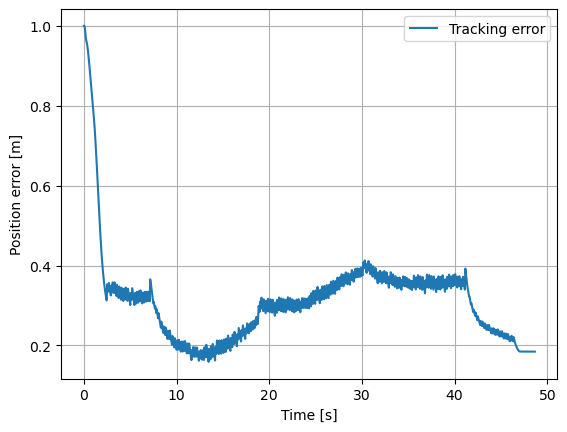

In [51]:
plt.figure()
plt.plot(t, e_pos, label="Tracking error")
plt.xlabel("Time [s]")
plt.ylabel("Position error [m]")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
rmse = np.sqrt(np.mean(e_pos**2))

print(f"RMSE: {rmse:.3f} m")


RMSE: 0.335 m
Mean error: 0.313 m
Max error: 1.000 m


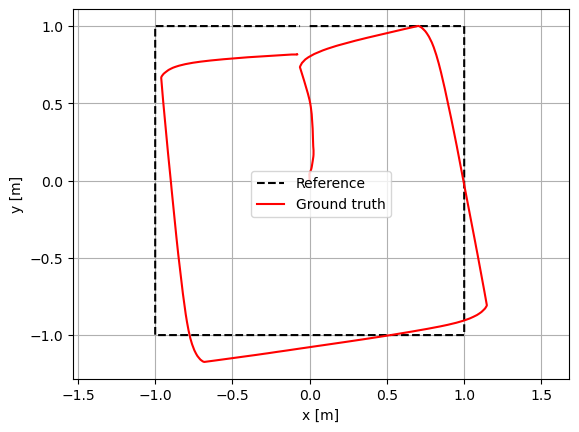

In [53]:
plt.figure()
plt.plot(goals["x"], goals["y"], "k--", label="Reference")
plt.plot(gt["x"], gt["y"], "r", label="Ground truth")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.grid(True)
plt.show()
